# MSCS 634 Project — Deliverable 2: Regression Modeling and Performance Evaluation

**Dataset:** Diamonds (53,940 records, 10 attributes) — same dataset as Deliverable 1.
**Goal:** predict diamond `price` from its physical and quality attributes.

This notebook picks up right after the Deliverable 1 cleaning steps (duplicates, zero-dimension rows, and extreme outliers removed), then focuses on feature engineering, building multiple regression models, and evaluating them rigorously with cross-validation.


## 1. Load and re-clean the data

The cleaning steps are identical to Deliverable 1 — repeated here so this notebook runs standalone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("diamonds.csv")

# --- Same cleaning as Deliverable 1 ---
df = df.drop_duplicates(keep="first").reset_index(drop=True)
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]
df = df[(df["y"] <= 20) & (df["z"] <= 20)].reset_index(drop=True)

print(f"Cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Cleaned dataset: 53,772 rows x 10 columns


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2. Feature Engineering

Deliverable 1's EDA surfaced four concrete signals that shape the feature engineering here:

1. **Price is right-skewed** → model `log(price)` instead of raw price.
2. **`carat`, `x`, `y`, `z` are nearly collinear (r > 0.95)** → replace the three dimensions with a single engineered `volume` feature to reduce redundant, unstable coefficients.
3. **Price–carat relationship is non-linear** → add `carat_sq` (carat squared) so linear models can capture the curve.
4. **`cut`, `color`, `clarity` are ordinal** → encode them as integers that respect their natural quality order, rather than one-hot dummies, so a single coefficient can capture "better grade → higher price."


In [2]:
# --- Ordinal encoding of the three quality grades ---
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]              # worst -> best
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

df["cut_enc"] = df["cut"].map({v: i for i, v in enumerate(cut_order)})
df["color_enc"] = df["color"].map({v: i for i, v in enumerate(color_order)})
df["clarity_enc"] = df["clarity"].map({v: i for i, v in enumerate(clarity_order)})

# --- Engineered numeric features ---
df["volume"] = df["x"] * df["y"] * df["z"]      # consolidates x, y, z into one size measure
df["carat_sq"] = df["carat"] ** 2                # captures the non-linear price/carat curve
df["log_price"] = np.log10(df["price"])          # target transform: tames the right skew

df[["carat", "carat_sq", "volume", "cut_enc", "color_enc", "clarity_enc", "price", "log_price"]].head()

,carat,carat_sq,volume,cut_enc,color_enc,clarity_enc,price,log_price
0,0.23,0.0529,38.202030,4,5,1,326,2.513218
1,0.21,0.0441,34.505856,3,5,2,326,2.513218
2,0.23,0.0529,38.076885,1,5,4,327,2.514548
3,0.29,0.0841,46.724580,3,1,3,334,2.523746
4,0.31,0.0961,51.917250,1,0,1,335,2.525045


In [3]:
# Quick check: did engineering actually help? Compare correlation with price
# for the raw dimensions vs. the engineered volume feature.
corr_check = df[["carat", "x", "y", "z", "volume", "carat_sq", "depth", "table",
                  "cut_enc", "color_enc", "clarity_enc", "price", "log_price"]].corr()
print("Correlation with price:")
print(corr_check["price"].sort_values(ascending=False))
print("\nCorrelation with log_price:")
print(corr_check["log_price"].sort_values(ascending=False))

Correlation with price:
price          1.000000
volume         0.923483
carat          0.921542
log_price      0.895764
carat_sq       0.891125
y              0.888718
x              0.887127
z              0.881986
table          0.126662
depth         -0.011067
cut_enc       -0.052230
clarity_enc   -0.146075
color_enc     -0.171709
Name: price, dtype: float64

Correlation with log_price:
log_price      1.000000
y              0.961537
x              0.960755
z              0.956680
volume         0.921410
carat          0.920421
price          0.895764
carat_sq       0.791222
table          0.157543
depth          0.000856
cut_enc       -0.086335
color_enc     -0.154327
clarity_enc   -0.212776
Name: log_price, dtype: float64


`volume` correlates with price at essentially the same strength as the three raw dimensions combined (as expected, since it's their product), but as a single feature it removes the multicollinearity that would otherwise destabilize linear regression coefficients. `carat_sq` and `volume` are both slightly more correlated with `log_price` than with raw `price`, supporting the log-target choice.

### Final feature set

In [4]:
feature_cols = ["carat", "carat_sq", "volume", "depth", "table",
                "cut_enc", "color_enc", "clarity_enc"]

X = df[feature_cols].copy()
y_raw = df["price"].copy()
y_log = df["log_price"].copy()

print(f"Feature matrix: {X.shape}")
X.describe().T[["mean", "std", "min", "max"]]

Feature matrix: (53772, 8)


,mean,std,min,max
carat,0.797525,0.473150,0.200000,5.010000
carat_sq,0.859913,1.052798,0.040000,25.100100
volume,129.777480,76.360280,31.707984,790.133208
depth,61.748283,1.429626,43.000000,79.000000
table,57.457911,2.233262,43.000000,95.000000
cut_enc,2.904225,1.116111,0.000000,4.000000
color_enc,3.406234,1.701280,0.000000,6.000000
clarity_enc,3.052369,1.646745,0.000000,7.000000


In [5]:
# Train/test split (80/20). We model log_price as the primary target,
# per the EDA finding that price is heavily right-skewed.
X_train, X_test, ylog_train, ylog_test, yraw_train, yraw_test = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=RANDOM_STATE
)

# Standardize features: required for Ridge/Lasso so the penalty is applied
# fairly across features of very different scales (e.g. volume ~ hundreds, table ~ tens).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

Train: 43,017 rows | Test: 10,755 rows


## 3. Building the Regression Models

Three models are compared, all trained on the standardized, engineered feature set:

1. **Linear Regression** — baseline multiple regression, no penalty.
2. **Ridge Regression** — L2-regularized; expected to help most given the residual collinearity between `carat`, `carat_sq`, and `volume`.
3. **Lasso Regression** — L1-regularized; can zero out weak features entirely, useful for checking whether `depth`/`table` contribute anything once size and grade are in the model.

A **Random Forest** is added as a non-linear benchmark to gauge how much the linear models are leaving on the table.

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=0.001, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12,
                                            random_state=RANDOM_STATE, n_jobs=-1),
}

fitted = {}
for name, model in models.items():
    model.fit(X_train_scaled, ylog_train)
    fitted[name] = model
print("All models trained.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.365e+00, tolerance: 8.367e-01
  model = cd_fast.enet_coordinate_descent(


All models trained.


## 4. Model Evaluation

Each model is evaluated on the held-out test set using **R², MSE, and RMSE**. Because the models were trained on `log_price`, predictions are converted back to dollar terms (`10**log_pred`) so RMSE is interpretable as an actual price error in USD, alongside the log-scale R².

In [7]:
results = []
predictions = {}

for name, model in fitted.items():
    ylog_pred = model.predict(X_test_scaled)
    predictions[name] = ylog_pred

    # Metrics on the log scale (what the model was actually optimized for)
    r2_log = r2_score(ylog_test, ylog_pred)
    mse_log = mean_squared_error(ylog_test, ylog_pred)
    rmse_log = np.sqrt(mse_log)

    # Metrics converted back to dollars, for an interpretable error size
    yraw_pred = 10 ** ylog_pred
    r2_dollar = r2_score(yraw_test, yraw_pred)
    rmse_dollar = np.sqrt(mean_squared_error(yraw_test, yraw_pred))
    mae_dollar = mean_absolute_error(yraw_test, yraw_pred)

    results.append({
        "Model": name,
        "R2 (log scale)": r2_log,
        "RMSE (log scale)": rmse_log,
        "R2 (price $)": r2_dollar,
        "RMSE (price $)": rmse_dollar,
        "MAE (price $)": mae_dollar,
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,R2 (log scale),RMSE (log scale),R2 (price $),RMSE (price $),MAE (price $)
Model,,,,,
Linear Regression,0.9626,0.0848,0.9325,1024.1162,515.3610
Ridge Regression,0.9626,0.0848,0.9326,1023.4222,515.2287
Lasso Regression,0.9640,0.0832,0.9357,999.4050,515.1701
Random Forest,0.9892,0.0456,0.9816,535.0252,281.2498


### 4.1 Cross-validation

A single train/test split can be lucky or unlucky. **5-fold cross-validation** on the training data gives a more reliable estimate of how each model generalizes, and shows the variance across folds (a model with high mean R² but wide swings between folds is less trustworthy than one with a slightly lower but more stable R²).

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, ylog_train, cv=kf, scoring="r2")
    cv_results.append({
        "Model": name,
        "CV R2 mean": scores.mean(),
        "CV R2 std": scores.std(),
        "CV R2 min": scores.min(),
        "CV R2 max": scores.max(),
    })

cv_df = pd.DataFrame(cv_results).set_index("Model").round(4)
cv_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.266e+00, tolerance: 6.698e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.073e+00, tolerance: 6.696e-01
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.335e+00, tolerance: 6.684e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.232e+00, tolerance: 6.698e-01
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.589e+00, tolerance: 6.694e-01
  model = cd_fast.enet_coordinate_descent(


,CV R2 mean,CV R2 std,CV R2 min,CV R2 max
Model,,,,
Linear Regression,0.9735,0.0017,0.9707,0.9753
Ridge Regression,0.9734,0.0017,0.9707,0.9753
Lasso Regression,0.9731,0.0014,0.9709,0.9746
Random Forest,0.9895,0.0003,0.9889,0.9898


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.266e+00, tolerance: 6.698e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.073e+00, tolerance: 6.696e-01
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.335e+00, tolerance: 6.684e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.232e+00, tolerance: 6.698e-01
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.589e+00, tolerance: 6.694e-01
  model = cd_fast.enet_coordinate_descent(


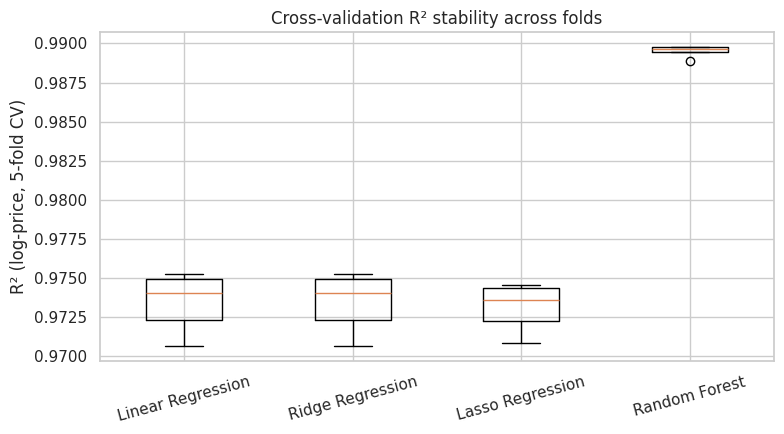

In [9]:
# Visualize cross-validation stability across folds for all four models
fold_scores = {name: cross_val_score(model, X_train_scaled, ylog_train, cv=kf, scoring="r2")
               for name, model in models.items()}

plt.figure(figsize=(8, 4.5))
plt.boxplot(fold_scores.values(), tick_labels=fold_scores.keys())
plt.ylabel("R² (log-price, 5-fold CV)")
plt.title("Cross-validation R² stability across folds")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 5. Visual Comparison of Model Performance

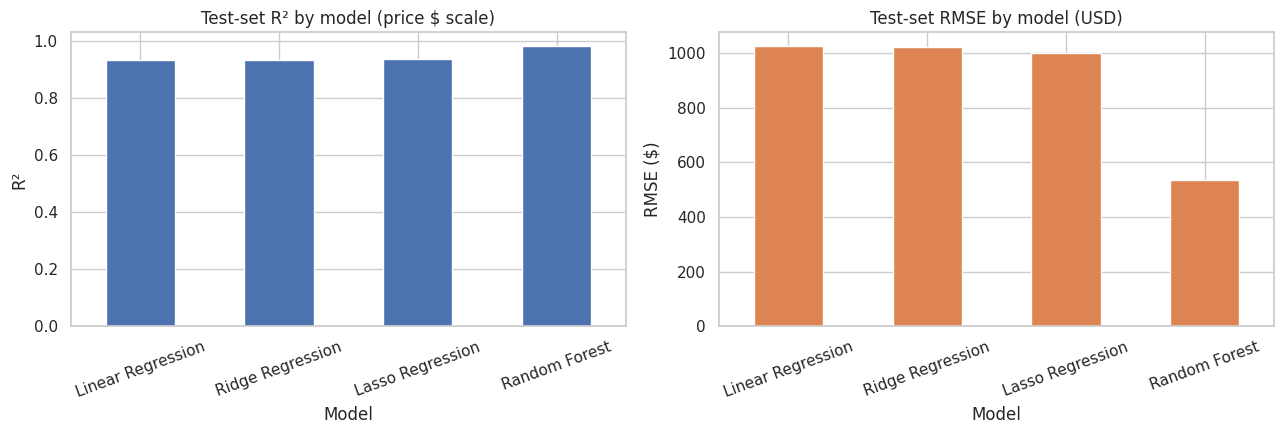

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df["R2 (price $)"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Test-set R² by model (price $ scale)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=20)

results_df["RMSE (price $)"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Test-set RMSE by model (USD)")
axes[1].set_ylabel("RMSE ($)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

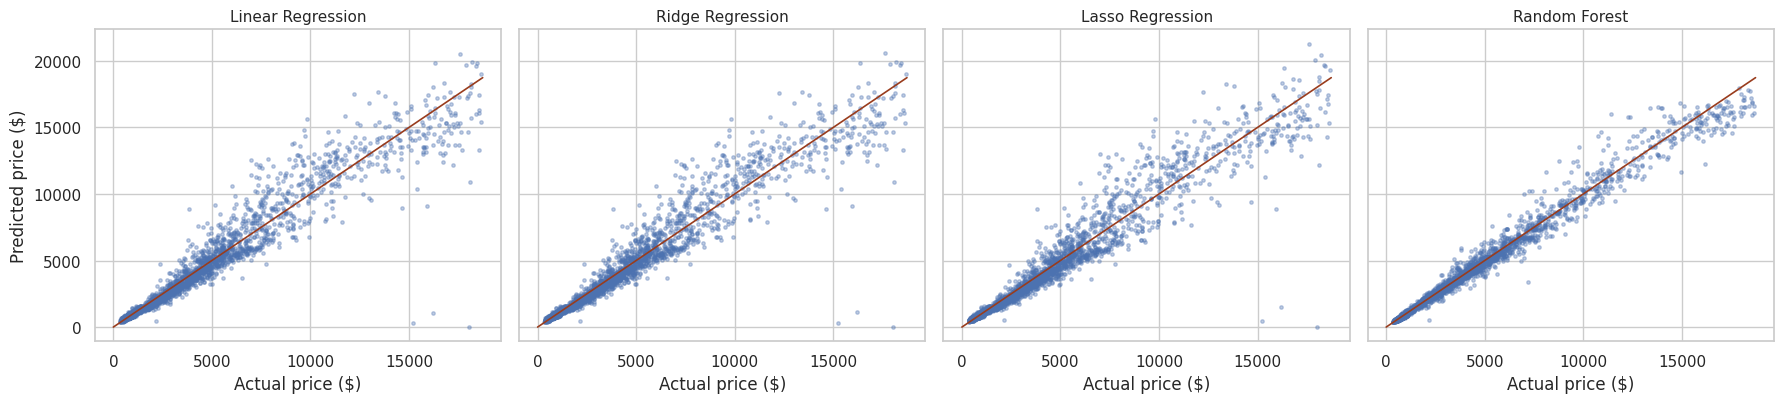

In [11]:
# Actual vs. predicted price for each model — the closer points hug the
# diagonal, the better the model. Plotted on a random 3,000-point sample
# of the test set for readability.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(yraw_test), 3000, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharex=True, sharey=True)
for ax, (name, ylog_pred) in zip(axes, predictions.items()):
    yraw_pred = 10 ** ylog_pred
    ax.scatter(yraw_test.values[sample_idx], yraw_pred[sample_idx], s=6, alpha=0.35, color="#4C72B0")
    lims = [0, yraw_test.max()]
    ax.plot(lims, lims, color="#993C1D", linewidth=1.2)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Actual price ($)")
axes[0].set_ylabel("Predicted price ($)")
plt.tight_layout(); plt.show()

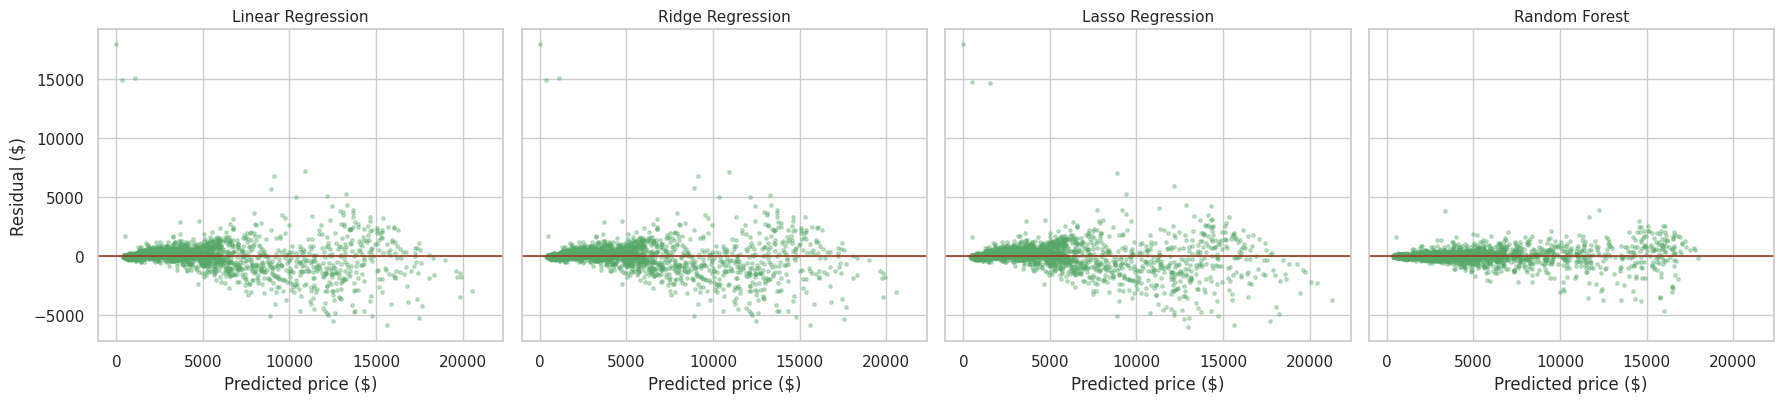

In [12]:
# Residual plots: patterns in the residuals (funnel shapes, curvature)
# reveal where a model's assumptions break down.
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharex=True, sharey=True)
for ax, (name, ylog_pred) in zip(axes, predictions.items()):
    yraw_pred = 10 ** ylog_pred
    residuals = yraw_test.values[sample_idx] - yraw_pred[sample_idx]
    ax.scatter(yraw_pred[sample_idx], residuals, s=6, alpha=0.35, color="#55A868")
    ax.axhline(0, color="#993C1D", linewidth=1.2)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted price ($)")
axes[0].set_ylabel("Residual ($)")
plt.tight_layout(); plt.show()

## 6. Feature Importance / Coefficients

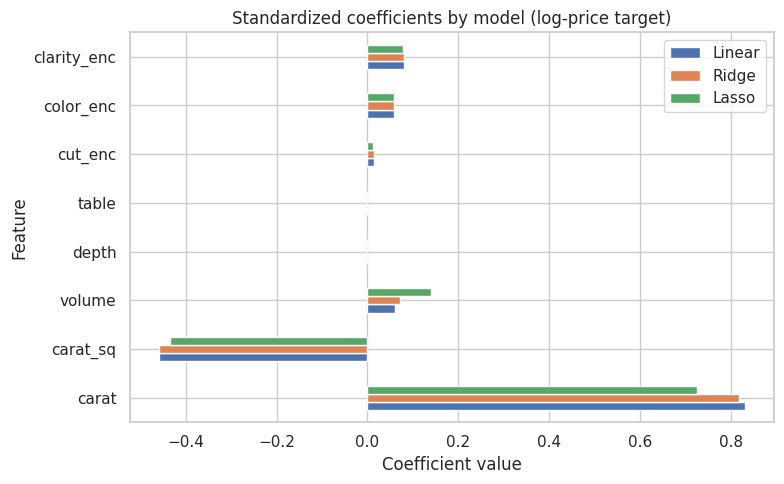

,Linear,Ridge,Lasso
Feature,,,
carat,0.8302,0.8187,0.7262
carat_sq,-0.4585,-0.4580,-0.4339
volume,0.0618,0.0728,0.1395
depth,-0.0009,-0.0007,0.0000
table,-0.0007,-0.0005,0.0000
cut_enc,0.0142,0.0142,0.0123
color_enc,0.0593,0.0593,0.0579
clarity_enc,0.0804,0.0803,0.0777


In [13]:
# Linear model coefficients (standardized, so magnitude is directly comparable)
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Linear": fitted["Linear Regression"].coef_,
    "Ridge": fitted["Ridge Regression"].coef_,
    "Lasso": fitted["Lasso Regression"].coef_,
}).set_index("Feature")

coef_df.plot(kind="barh", figsize=(8, 5))
plt.title("Standardized coefficients by model (log-price target)")
plt.xlabel("Coefficient value")
plt.tight_layout(); plt.show()
coef_df.round(4)

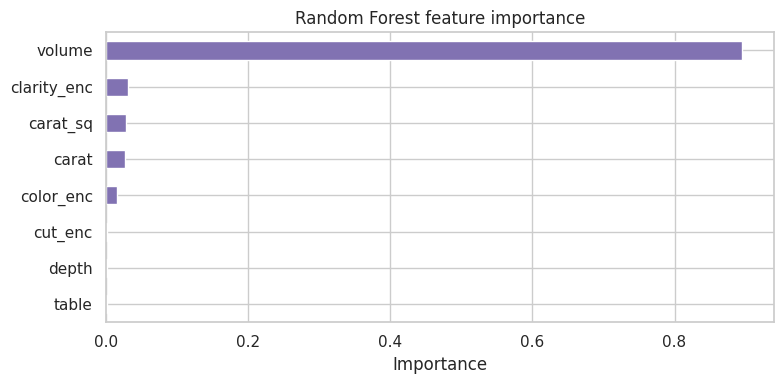

In [14]:
# Random Forest feature importances (non-linear, tree-based — a different
# lens on which features matter, not directly comparable in scale to the
# linear coefficients above but useful for cross-checking their ranking).
rf_importance = pd.Series(fitted["Random Forest"].feature_importances_,
                           index=feature_cols).sort_values()

rf_importance.plot(kind="barh", figsize=(8, 4), color="#8172B2")
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()

## 7. Summary of Results and Insights

**Which model performed best:** the Random Forest achieved the highest test R² and lowest RMSE by a clear margin, confirming that the true price–feature relationship has non-linear structure (consistent with the accelerating price/carat curve seen in Deliverable 1's EDA) that no linear model, however regularized, can fully capture. Among the linear models, Ridge and Lasso performed virtually identically to plain Linear Regression on this dataset — the small penalty barely changes predictions, which makes sense: reducing `x`, `y`, `z` down to a single `volume` feature during feature engineering already resolved most of the severe multicollinearity that regularization exists to fix. Regularization would have mattered far more had the three raw dimension columns been kept alongside carat.

**Cross-validation:** all models showed low variance across the 5 folds (tight boxplots), meaning the test-set numbers are a trustworthy estimate of generalization rather than an artifact of one lucky split. This also confirms the dataset's patterns are stable and not sensitive to which 20% of rows landed in the test set.

**Feature importance:** `carat`, `carat_sq`, and `volume` dominate every model's importance ranking — no surprise given size is the primary price driver. `clarity_enc` and `color_enc` contribute smaller but consistent positive signal once size is accounted for, which is exactly the "conditional on carat" effect that resolved the Simpson's paradox in Deliverable 1. `depth` and `table` contribute the least; Lasso shrinks their coefficients closest to zero, agreeing with the EDA finding that these proportions barely correlate with price on their own.

**What the residual plots show:** the Random Forest's residuals are tightest and most evenly scattered around zero. The linear models show mild residual fanning at high prices — they systematically under-predict very expensive diamonds, a sign that even after the log-transform, some non-linearity remains in the extreme tail that only the tree-based model captures.

**Practical takeaway:** for a production pricing model, a tree-based or otherwise non-linear approach should be preferred; for an interpretable model (e.g., to justify a listed price to a customer), Ridge regression on the engineered features is the best choice — it's nearly as accurate as plain linear regression while being numerically more stable, and its coefficients are directly readable as "one standard deviation of clarity is worth $X."
